# Global sensitivity analysis: Mass-action kinetics, double binding 

Nathaniel Linden (UCSD MAE) - March  2023

In [2]:
import sunode
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import sympy as sym
from SALib.sample import sobol as sobol_samp
from SALib.sample import morris as morris_samp
from SALib.analyze import sobol as sobol_analyze
from SALib.analyze import morris as morris_analyze
from SALib.analyze.hdmr import analyze as hdmr_analyze
import seaborn as sns
import sys
import time
import multiprocessing
from tqdm import tqdm
from joblib import Parallel, delayed
sys.path.insert(0, '../odes')

import ampk_MA_double_mech as model1
%matplotlib inline
plt.style.use('~/.matplotlib/custom.mplstyle')
mpl.rcParams['figure.autolayout'] = True
plt.rcParams['text.usetex'] = False
mpl.rcParams['text.usetex'] = False
# plt.rcParams['mathtext.fontset']='dejavusans'

In [3]:
# We need some info form the subode problem to get correct types for things
# load the necessary dictionaries
params = model1.ampk_MA_double_mech_get_params()
states = model1.ampk_MA_double_mech_get_states()
nparams = len(params)
nstates = len(states)

# create sunode problem
problem_ode = sunode.SympyProblem(
    params=params,
    states=states,
    rhs_sympy=model1.ampk_MA_double_mech_RHS,
    # specify variables to take gradients wrt
    derivative_params=(),
)

First, we want to plot how well the steady-state checking algorithm is working...

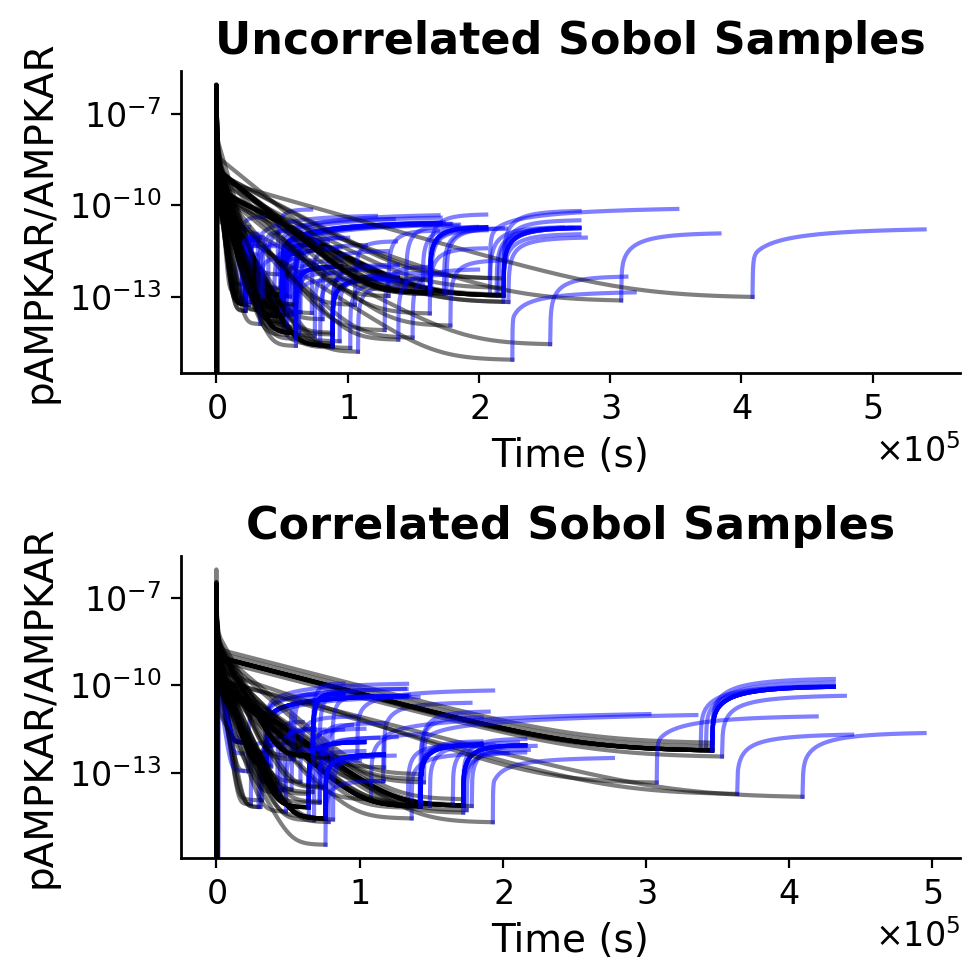

In [4]:
fig, ax = plt.subplots(2,1, figsize=(5,5))
sobol_sols_short = np.load('./MA_double_mech/sols_sobol_short.npy', allow_pickle=True)
sobol_sols_corr_short = np.load('./MA_double_mech/sols_sobol_corr_short.npy', allow_pickle=True)
for a in sobol_sols_short:
    ax[0].plot(a[3], a[1].view(problem_ode.state_dtype)['pAMPKAR']/a[1].view(problem_ode.state_dtype)['AMPKAR'],
            'k', alpha=0.5)
    ax[0].plot(1+a[3][-1]+a[4], a[2].view(problem_ode.state_dtype)['pAMPKAR']/a[2].view(problem_ode.state_dtype)['AMPKAR'],
            'b', alpha=0.5)
    
for a in sobol_sols_corr_short:
    ax[1].plot(a[3], a[1].view(problem_ode.state_dtype)['pAMPKAR']/a[1].view(problem_ode.state_dtype)['AMPKAR'],
            'k', alpha=0.5)
    ax[1].plot(1+a[3][-1]+a[4], a[2].view(problem_ode.state_dtype)['pAMPKAR']/a[2].view(problem_ode.state_dtype)['AMPKAR'],
            'b', alpha=0.5)
ax[0].set_yscale('log')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('pAMPKAR/AMPKAR')
ax[0].set_title('Uncorrelated Sobol Samples')

ax[1].set_yscale('log')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('pAMPKAR/AMPKAR')
ax[1].set_title('Correlated Sobol Samples')
fig.savefig('./MA_double_mech/sobol_corr_ss_check.pdf')

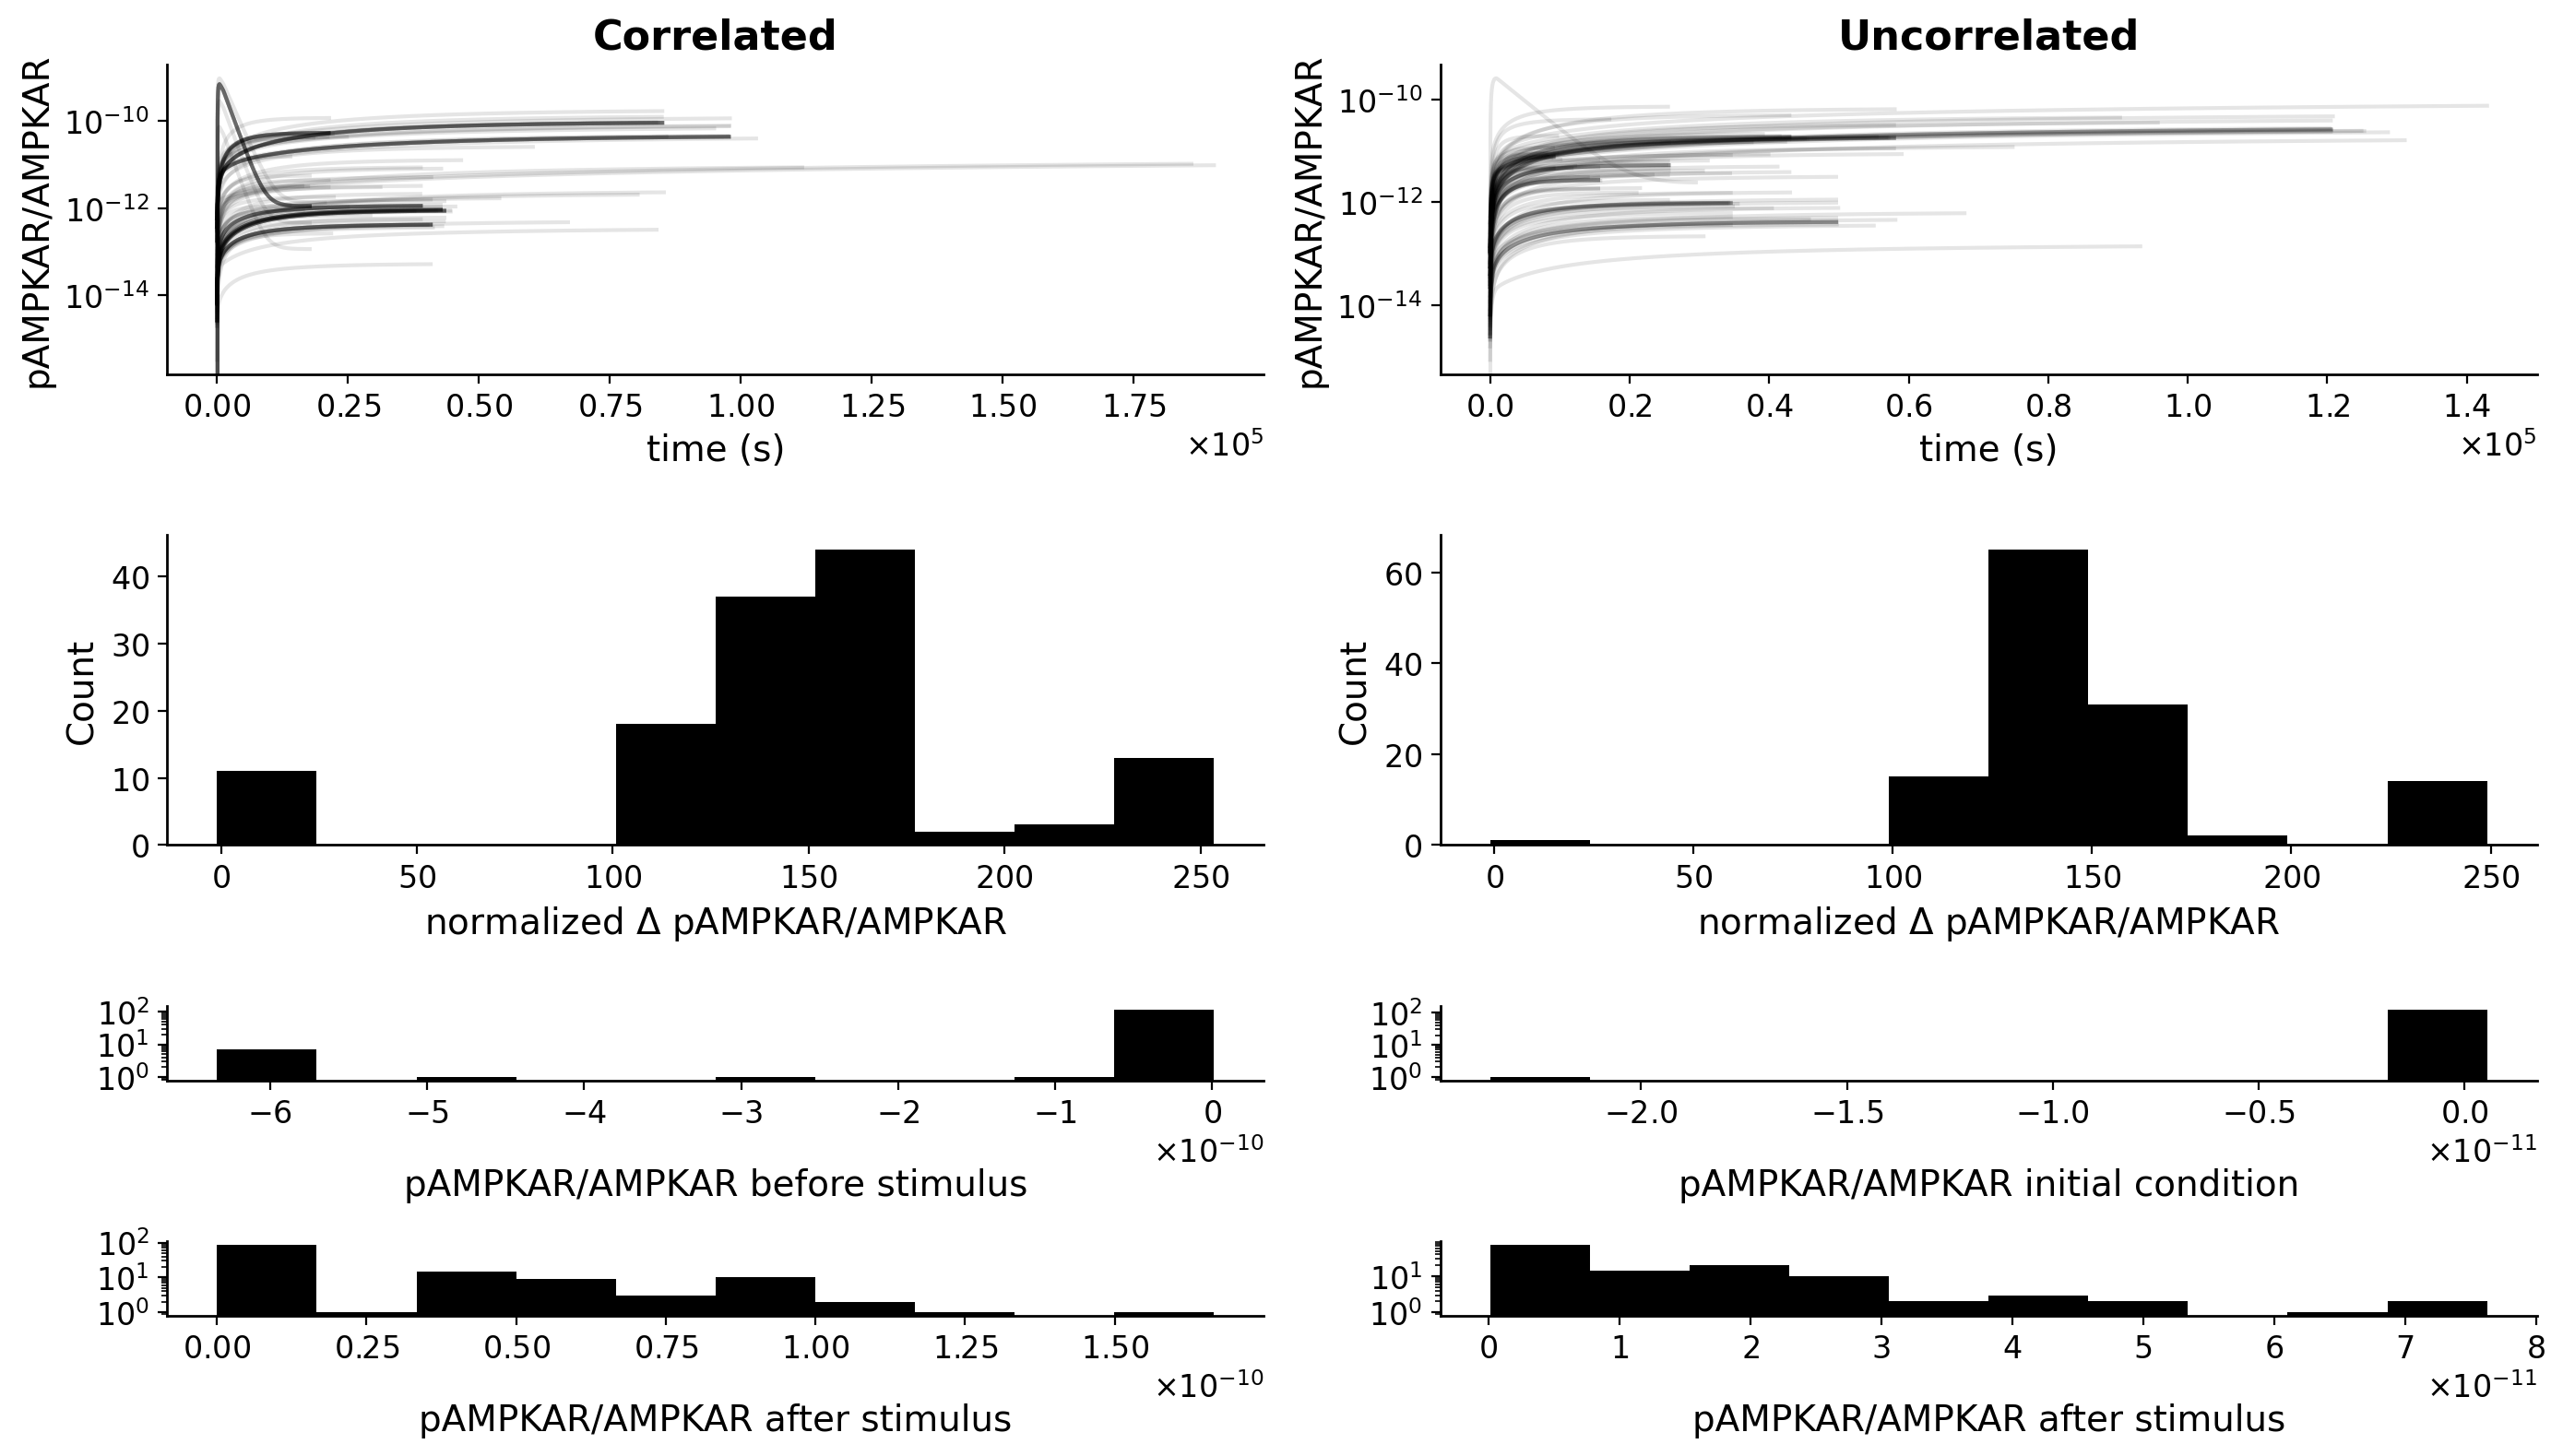

In [5]:
# if 'sobol_sols_short' in vars():
#     del sobol_sols_short
# morris_sols_corr_short = np.load('./MA_double_mech/sols_morris_corr_short.npy', allow_pickle=True)
# plot the solutions
# fig, ax = plt.subplots(3, 2, figsize=(10,10))
# f, (a0, a1) = plt.subplots(1, 2, height_ratios=[3, 1])
fig, ax = plt.subplot_mosaic(
    [['traj A', 'traj B'],
     ['traj A', 'traj B'],
     ['hist A', 'hist B'],
     ['hist A', 'hist B'],
     ['hist C', 'hist D'],
     ['hist E', 'hist F']],figsize=(14,8))
# fig, ax = plt.subplot_mosaic(
#     [['traj A'],
#      ['traj A'],
#      ['hist A'],
#      ['hist A'],
#      ['hist C'],
#      ['hist E']],figsize=(14,8))
for sol in sobol_sols_corr_short:
    ax['traj A'].plot(sol[4], sol[2].view(problem_ode.state_dtype)['pAMPKAR']/sol[2].view(problem_ode.state_dtype)['AMPKAR'], color='k', alpha=0.1)
ax['hist A'].hist(np.array([sol[0][1] for sol in sobol_sols_corr_short]), color='k')
ax['hist C'].hist(np.array([sol[0][0] for sol in sobol_sols_corr_short]), color='k')
ax['hist E'].hist(np.array([sol[0][1]*sol[0][0]+sol[0][0] for sol in sobol_sols_corr_short]), color='k')

    

for sol in sobol_sols_short:
    ax['traj B'].plot(sol[4], sol[2].view(problem_ode.state_dtype)['pAMPKAR']/sol[2].view(problem_ode.state_dtype)['AMPKAR'], color='k', alpha=0.1)
ax['hist B'].hist(np.array([sol[0][1] for sol in sobol_sols_short]), color='k')
ax['hist D'].hist(np.array([sol[0][0] for sol in sobol_sols_short]), color='k')
ax['hist F'].hist(np.array([sol[0][1]*sol[0][0]+sol[0][0] for sol in sobol_sols_short]), color='k')


# plot formatting
ax['traj A'].set_xlabel('time (s)')
ax['traj A'].set_ylabel('pAMPKAR/AMPKAR')
ax['traj A'].set_title('Correlated')
ax['traj A'].set_yscale('log')

ax['hist A'].set_xlabel('normalized $\Delta$ pAMPKAR/AMPKAR')
ax['hist A'].set_ylabel('Count')
# ax['hist A'].set_xlim([0.0, 200.0])

ax['hist C'].set_xlabel('pAMPKAR/AMPKAR before stimulus', labelpad=15)
ax['hist C'].set_yscale('log')

ax['hist E'].set_xlabel('pAMPKAR/AMPKAR after stimulus', labelpad=15)
ax['hist E'].set_yscale('log')

ax['traj B'].set_xlabel('time (s)')
ax['traj B'].set_ylabel('pAMPKAR/AMPKAR')
ax['traj B'].set_title('Uncorrelated')
ax['traj B'].set_yscale('log')

ax['hist B'].set_xlabel('normalized $\Delta$ pAMPKAR/AMPKAR')
ax['hist B'].set_ylabel('Count')
# ax['hist B'].set_xlim([0.0, 200.0])

ax['hist D'].set_xlabel('pAMPKAR/AMPKAR initial condition', labelpad=15)
ax['hist D'].set_yscale('log')

ax['hist F'].set_xlabel('pAMPKAR/AMPKAR after stimulus', labelpad=15)
ax['hist F'].set_yscale('log')
fig.savefig('./MA_double_mech/bounds_test.pdf')

In [12]:
ss_pre = [sol[0][0] for sol in sobol_sols_corr_short]
print(sum([ss < 0.0 for ss in ss_pre]))

[11]


### Now load the parameter values and solutions for the actual analysis

In [13]:
# remove "short" runs 
if 'sobol_sols_corr_short' in vars():
    del sobol_sols_corr_short
if 'morris_sols_corr_short' in vars():
    del morris_sols_corr_short

# load samples
param_vals_sobol = np.load('./MA_double_mech/param_vals_sobol_MA.npy')
param_vals_sobol_corr = np.load('./MA_double_mech/param_vals_sobol_MA_corr.npy')

# load solutions
sobol_sols = np.load('./MA_double_mech/sols_sobol.npy')
sobol_sols_corr = np.load('./MA_double_mech/sols_sobol_corr.npy')

In [29]:
ss_pre = [(sol[0][0], idx) for sol, idx in zip(sobol_sols_corr, range(len(sobol_sols_corr)))]
print('There are', len(sobol_sols), 'total correlated Sobol samples.')
print(sum([ss[0] < 0.0 for ss in ss_pre]), 'of them have negative initial steady-states')

neg_idxs = []
for ss in ss_pre:
    if ss[0] <0.0:
        neg_idxs.append(ss[1])
param_vals_sobol_corr[neg_idxs]

There are 61440 total correlated Sobol samples.
324 of them have negative initial steady-states


array([[4.02640547e-03, 1.66987866e-04, 4.87826254e-04, ...,
        1.91334623e+01, 1.23327560e-01, 1.39627611e-03],
       [4.02640547e-03, 1.66987866e-04, 1.33451217e-03, ...,
        1.91334623e+01, 1.23327560e-01, 1.39627611e-03],
       [4.02640547e-03, 1.66987866e-04, 1.33451217e-03, ...,
        1.91334623e+01, 1.23327560e-01, 1.39627611e-03],
       ...,
       [4.66346475e-03, 3.69494477e-04, 9.90467654e-04, ...,
        8.66981687e+00, 5.89377184e-02, 8.04761840e-04],
       [4.50900126e-03, 5.96551521e-04, 4.84205917e-04, ...,
        9.31763026e+00, 4.59381124e-02, 8.40990982e-04],
       [4.71373828e-03, 2.10182929e-04, 1.06140534e-03, ...,
        1.68207824e+01, 8.61935230e-02, 5.86201237e-04]])

In [62]:
############################################
# First for Mass action parameters
nominal_vals_MA = [
   2.5e-3, # KdAMP
   1.5e-3, # KdADP
   1.7e-3, # KdATP
   90.467, # kOnCaMKK = (koff+kphos/Km)
   0.357, # kPhosCaMKK
   0.742, # kOnLKB1
   3.92e-2, # kPhosLKB1
   16.56, # kOnPP
   1.1e-1, # kDephosPP
   1569.59, # kOnAMPK
   6.33, # kPhosAMPK
   16.56, # kOnPP1
   1.1e-1, # kDephosPP1
   1e-3, # AMPKAR
]

bounds_MA_90 = [[0.1*param, 1.9*param] for param in nominal_vals_MA]

param_names_MA = ['KdAMP', 'KdADP', 'KdATP', 'kOnCaMKK', 'kPhosCaMKK', 
               'kOnLKB1','kPhosLKB1','kOnPP','kDephosPP', 
               'kOnAMPK','kPhosAMPK', 'kOnPP1','kDephosPP1', 'AMPKAR']
state_names = ['AMP', 'ADP', 'ATP', 'AMPK', 'pAMPK', 'AMP_AMPK', 'ADP_AMPK', 
               'ATP_AMPK', 'AMP_pAMPK', 'ADP_pAMPK', 'ATP_pAMPK', 'AMP_AMP_AMPK', 
               'AMP_ADP_AMPK', 'AMP_ATP_AMPK', 'ADP_ADP_AMPK', 'ADP_ATP_AMPK', 'ATP_ATP_AMPK', 
               'AMP_AMP_pAMPK', 'AMP_ADP_pAMPK', 'AMP_ATP_pAMPK', 'ADP_ADP_pAMPK', 'ADP_ATP_pAMPK', 
               'ATP_ATP_pAMPK', 'CaMKK', 'CaMKK_AMPK', 'CaMKK_AMP_AMPK', 'CaMKK_ADP_AMPK', 'CaMKK_ATP_AMPK', 
               'CaMKK_AMP_AMP_AMPK', 'CaMKK_AMP_ADP_AMPK', 'CaMKK_AMP_ATP_AMPK', 'CaMKK_ADP_ADP_AMPK', 'CaMKK_ADP_ATP_AMPK', 
               'CaMKK_ATP_ATP_AMPK', 'LKB1', 'LKB1_AMP_AMPK', 'LKB1_ADP_AMPK', 'LKB1_AMP_AMP_AMPK', 'LKB1_AMP_ADP_AMPK', 
               'LKB1_ADP_ADP_AMPK', 'PP', 'PP_pAMPK', 'PP_ATP_pAMPK', 'PP_AMP_ATP_pAMPK', 'PP_ADP_ATP_pAMPK', 
               'PP_ATP_ATP_pAMPK', 'AMPKAR', 'pAMPKAR', 'AMPKAR_AMP_pAMPK', 'AMPKAR_AMP_AMP_pAMPK', 
               'AMPKAR_AMP_ADP_pAMPK', 'PP1', 'PP1_pAMPKAR']
problem_90 = {'num_vars':14, 'names':param_names_MA, 'bounds': bounds_MA_90,}

### Compute relevant sensitivity indices

We will compute sobol indices and the HDMR indices

In [149]:
# convert lists to numpy arrays and remove extra dimension
s_outputs_np = np.squeeze(np.array(sobol_sols))
s_outputs_corr_np = np.squeeze(np.array(sobol_sols_corr))

# # compute Sobol and Morris indices
# Si_sobol_ss = sobol_analyze.analyze(problem_90, s_outputs_np[:,0], calc_second_order=True)
# Si_sobol_delta = sobol_analyze.analyze(problem_90, s_outputs_np[:,1], calc_second_order=True)
# Si_sobol_corr_ss = sobol_analyze.analyze(problem_90, s_outputs_corr_np[:,0], calc_second_order=True)
# Si_sobol_corr_delta = sobol_analyze.analyze(problem_90, s_outputs_corr_np[:,1], calc_second_order=True)

# # compute HDMR indices
# Si_hdmr_ss = hdmr_analyze(problem_90, param_vals_sobol, s_outputs_np[:,0])
# Si_hdmr_delta = hdmr_analyze(problem_90, param_vals_sobol, s_outputs_np[:,1])
Si_hdmr_corr_ss = hdmr_analyze(problem_90, param_vals_sobol_corr, s_outputs_corr_np[:,0])
Si_hdmr_corr_delta = hdmr_analyze(problem_90, param_vals_sobol_corr, s_outputs_corr_np[:,1])

In [152]:
# sort sobol indices by ST
dtype = [('name', 'U10'), ('S1', float), ('S1_conf', float), ('ST', float), ('ST_conf', float)]
# sobol
Si_sobol_ss_sorted = np.array([(name, S1, S1_conf, ST, ST_conf) for 
                               name, S1, S1_conf, ST, ST_conf in zip(param_names_MA, Si_sobol_ss['S1'], Si_sobol_ss['S1_conf'], 
                                                                     Si_sobol_ss['ST'], Si_sobol_ss['ST'])], dtype=dtype)
Si_sobol_ss_sorted = np.sort(Si_sobol_ss_sorted, order='ST')[::-1]

Si_sobol_delta_sorted = np.array([(name, S1, S1_conf, ST, ST_conf) for 
                               name, S1, S1_conf, ST, ST_conf in zip(param_names_MA, Si_sobol_delta['S1'], Si_sobol_delta['S1_conf'], 
                                                                     Si_sobol_delta['ST'], Si_sobol_delta['ST'])], dtype=dtype)
Si_sobol_delta_sorted = np.sort(Si_sobol_delta_sorted, order='ST')[::-1]
# sobol corr
Si_sobol_corr_ss_sorted = np.array([(name, S1, S1_conf, ST, ST_conf) for 
                               name, S1, S1_conf, ST, ST_conf in zip(param_names_MA, Si_sobol_corr_ss['S1'], Si_sobol_corr_ss['S1_conf'], 
                                                                     Si_sobol_corr_ss['ST'], Si_sobol_corr_ss['ST'])], dtype=dtype)
Si_sobol_corr_ss_sorted = np.sort(Si_sobol_corr_ss_sorted, order='ST')[::-1]

Si_sobol_corr_delta_sorted = np.array([(name, S1, S1_conf, ST, ST_conf) for 
                               name, S1, S1_conf, ST, ST_conf in zip(param_names_MA, Si_sobol_corr_delta['S1'], Si_sobol_corr_delta['S1_conf'], 
                                                                     Si_sobol_corr_delta['ST'], Si_sobol_corr_delta['ST'])], dtype=dtype)
Si_sobol_corr_delta_sorted = np.sort(Si_sobol_corr_delta_sorted, order='ST')[::-1]



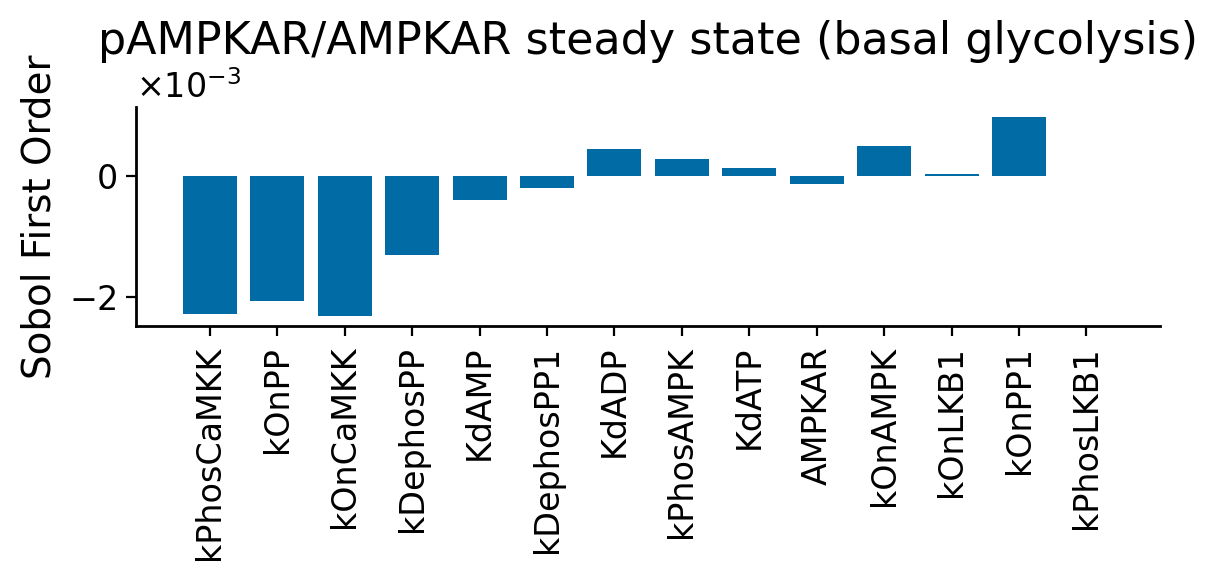

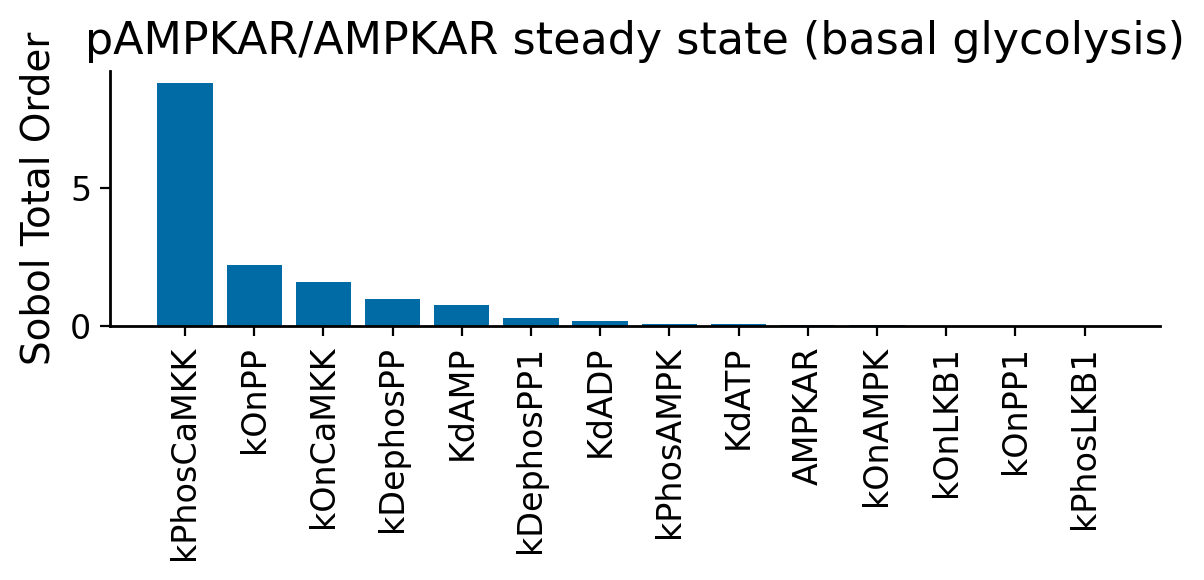

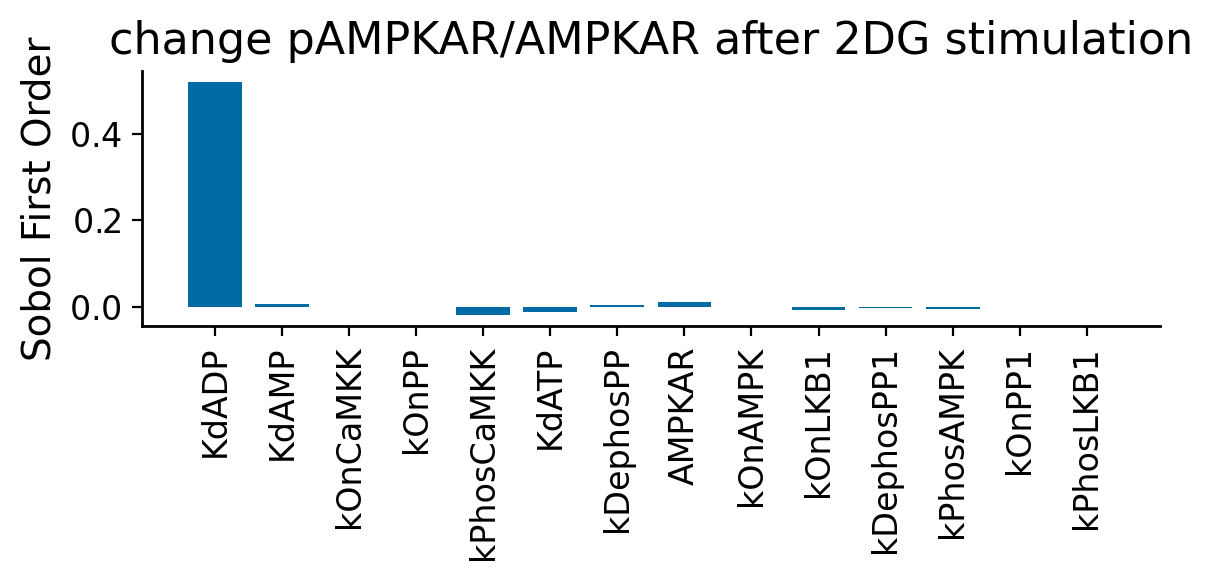

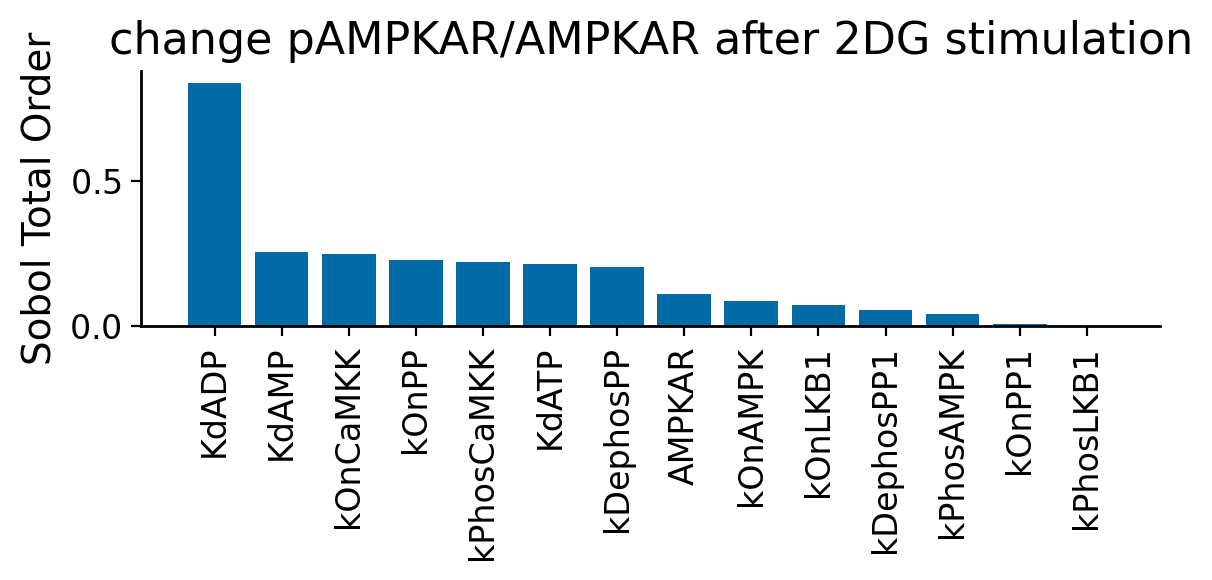

In [138]:
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_ss_sorted['S1'],
        # yerr=Si_sobol_ss_sorted['S1_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_ss_sorted['name'], rotation='vertical')
plt.ylabel('Sobol First Order')
plt.title('pAMPKAR/AMPKAR steady state (basal glycolysis)', weight='normal')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_S1_ss.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_ss_sorted['ST'],
        # yerr=Si_sobol_ss_sorted['ST_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_ss_sorted['name'], rotation='vertical')
plt.ylabel('Sobol Total Order')
plt.title('pAMPKAR/AMPKAR steady state (basal glycolysis)', weight='normal')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_ST_ss.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_delta_sorted['S1'],
        # yerr=Si_sobol_delta_sorted['S1_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol First Order')
plt.title('change pAMPKAR/AMPKAR after 2DG stimulation', weight='normal')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_S1_delta.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_delta_sorted['ST'],
        # yerr=Si_sobol_delta_sorted['ST_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol Total Order')
plt.title('change pAMPKAR/AMPKAR after 2DG stimulation', weight='normal')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_ST_delta.pdf')
plt.show()

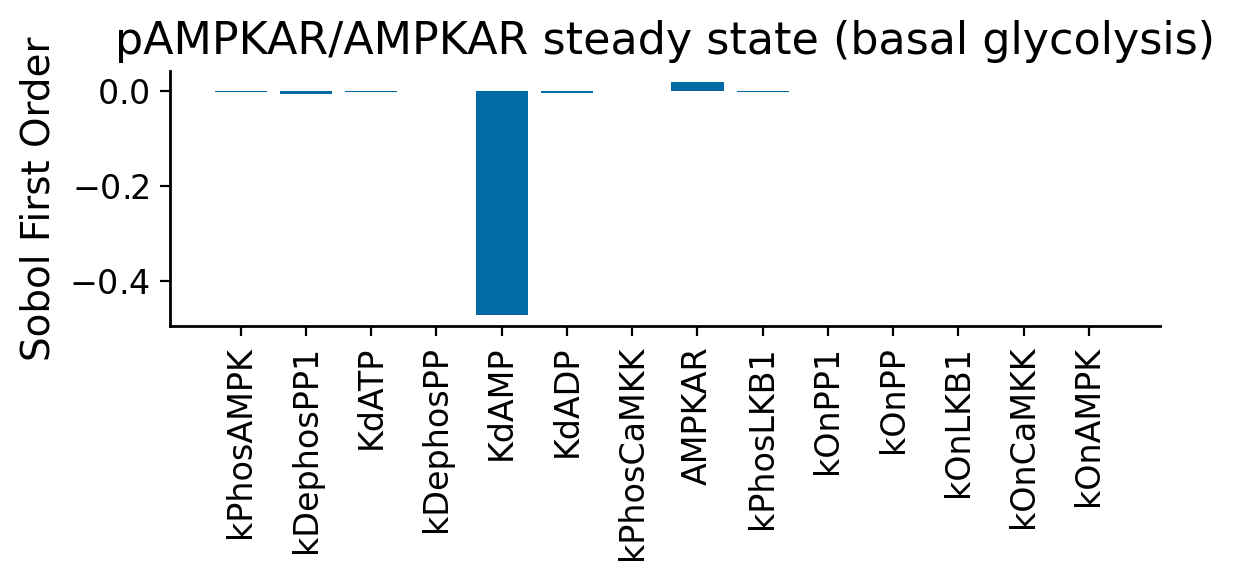

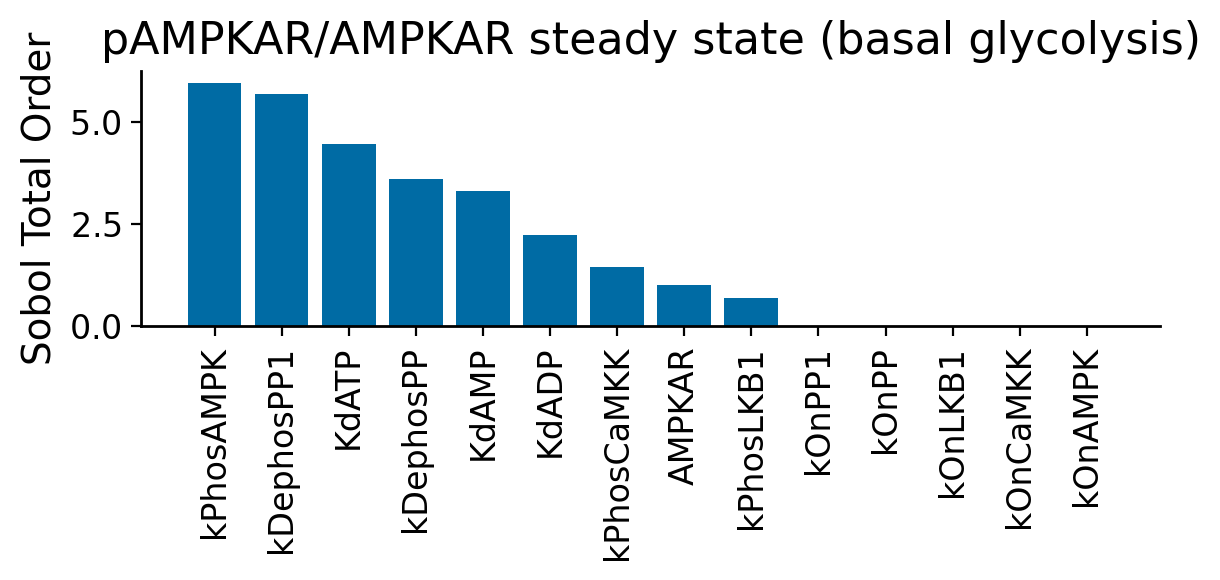

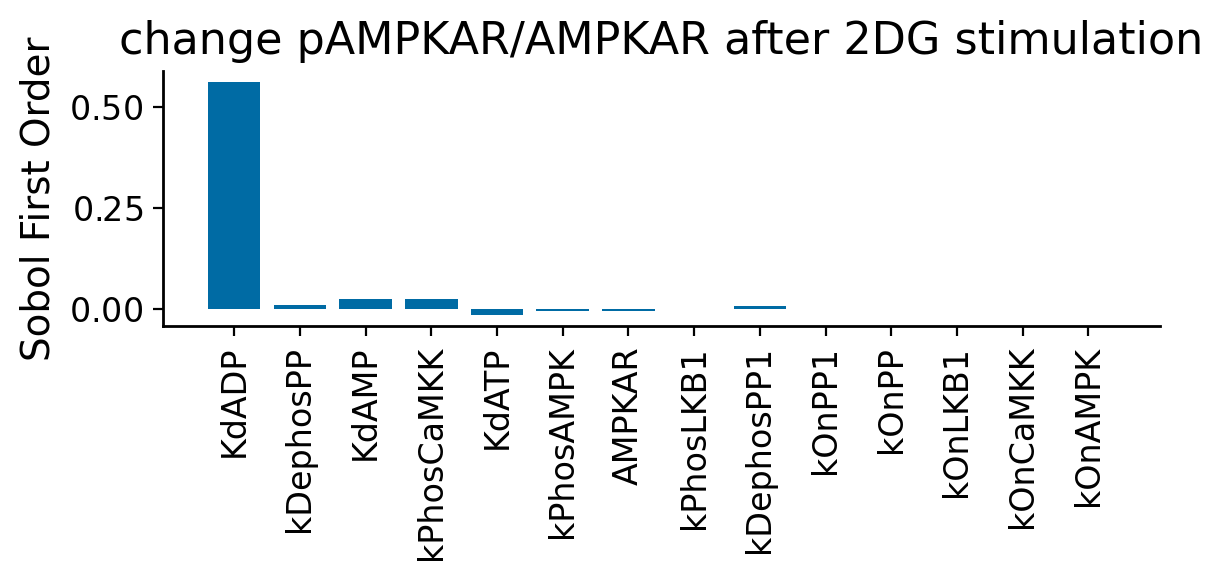

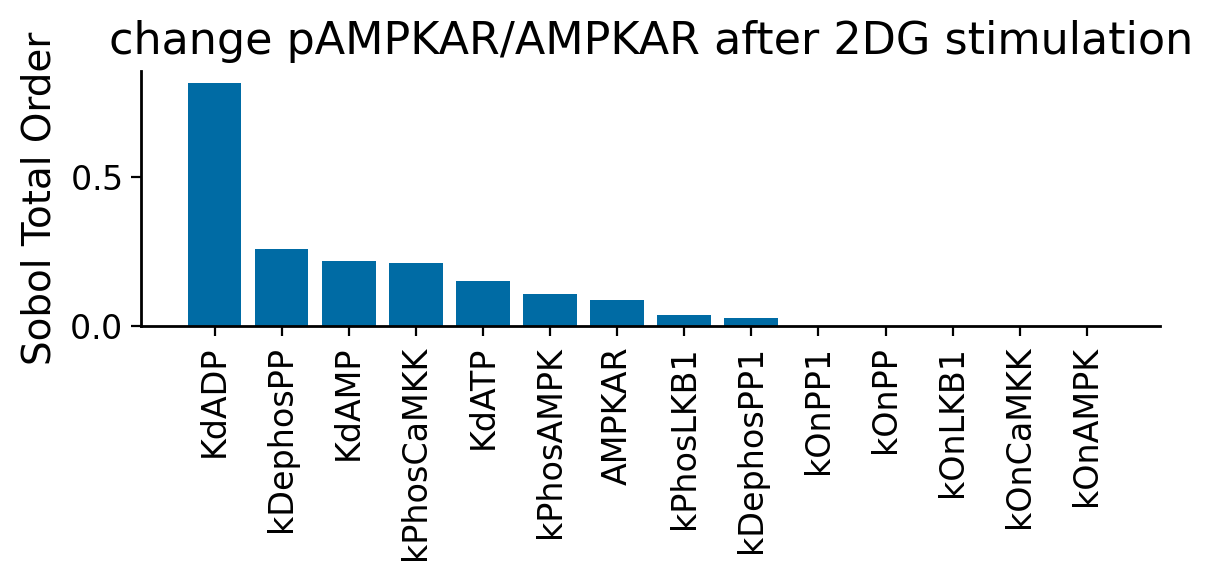

In [153]:
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_corr_ss_sorted['S1'],
        # yerr=Si_sobol_ss_sorted['S1_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_corr_ss_sorted['name'], rotation='vertical')
plt.ylabel('Sobol First Order')
plt.title('pAMPKAR/AMPKAR steady state (basal glycolysis)', weight='normal')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_S1_corr_ss.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_corr_ss_sorted['ST'],
        # yerr=Si_sobol_ss_sorted['ST_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_corr_ss_sorted['name'], rotation='vertical')
plt.ylabel('Sobol Total Order')
plt.title('pAMPKAR/AMPKAR steady state (basal glycolysis)', weight='normal')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_ST_corr_ss.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_corr_delta_sorted['S1'],
        # yerr=Si_sobol_delta_sorted['S1_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_corr_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol First Order')
plt.title('change pAMPKAR/AMPKAR after 2DG stimulation', weight='normal')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_S1_corr_delta.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_corr_delta_sorted['ST'],
        # yerr=Si_sobol_delta_sorted['ST_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_corr_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol Total Order')
plt.title('change pAMPKAR/AMPKAR after 2DG stimulation', weight='normal')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_ST_corr_delta.pdf')
plt.show()

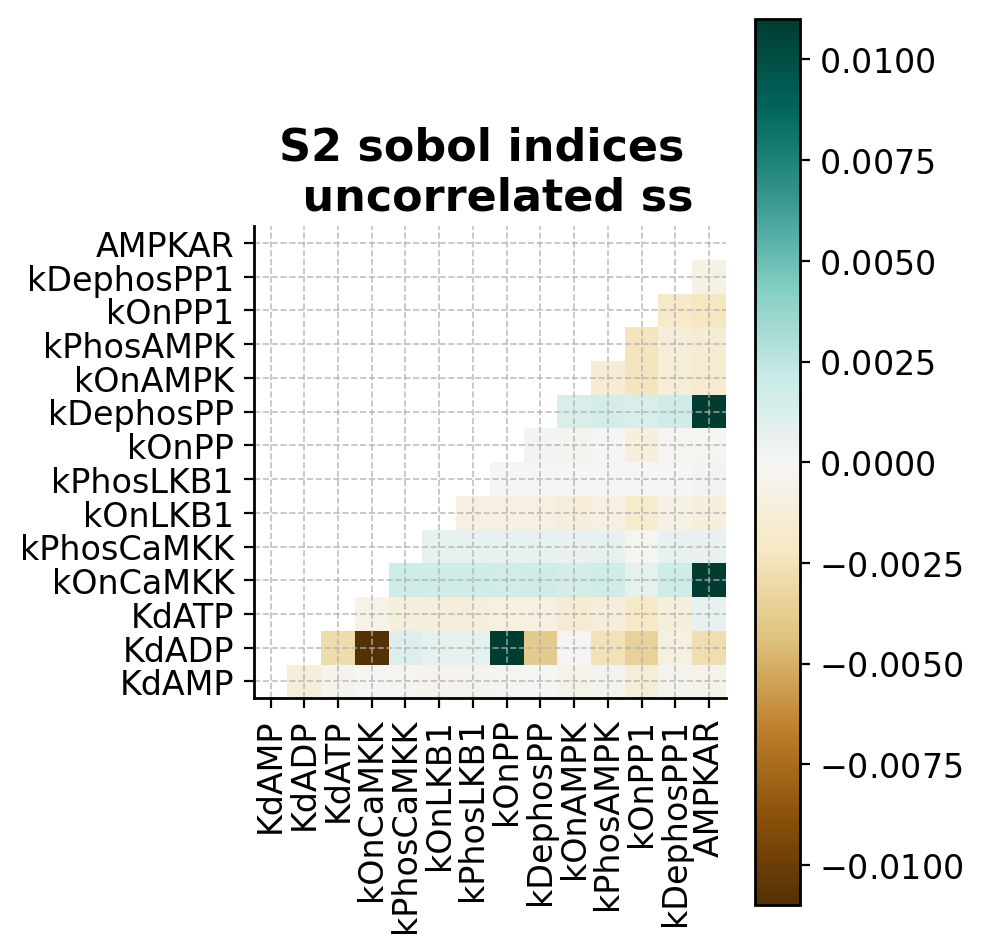

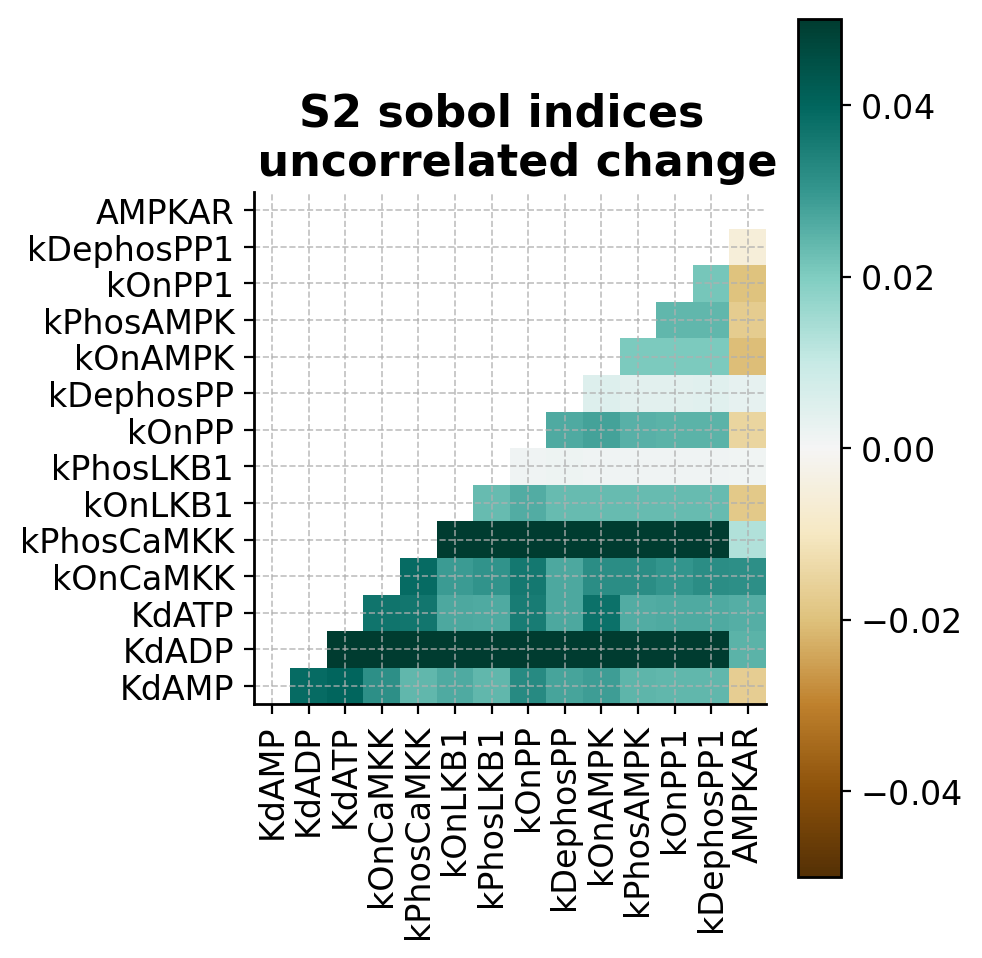

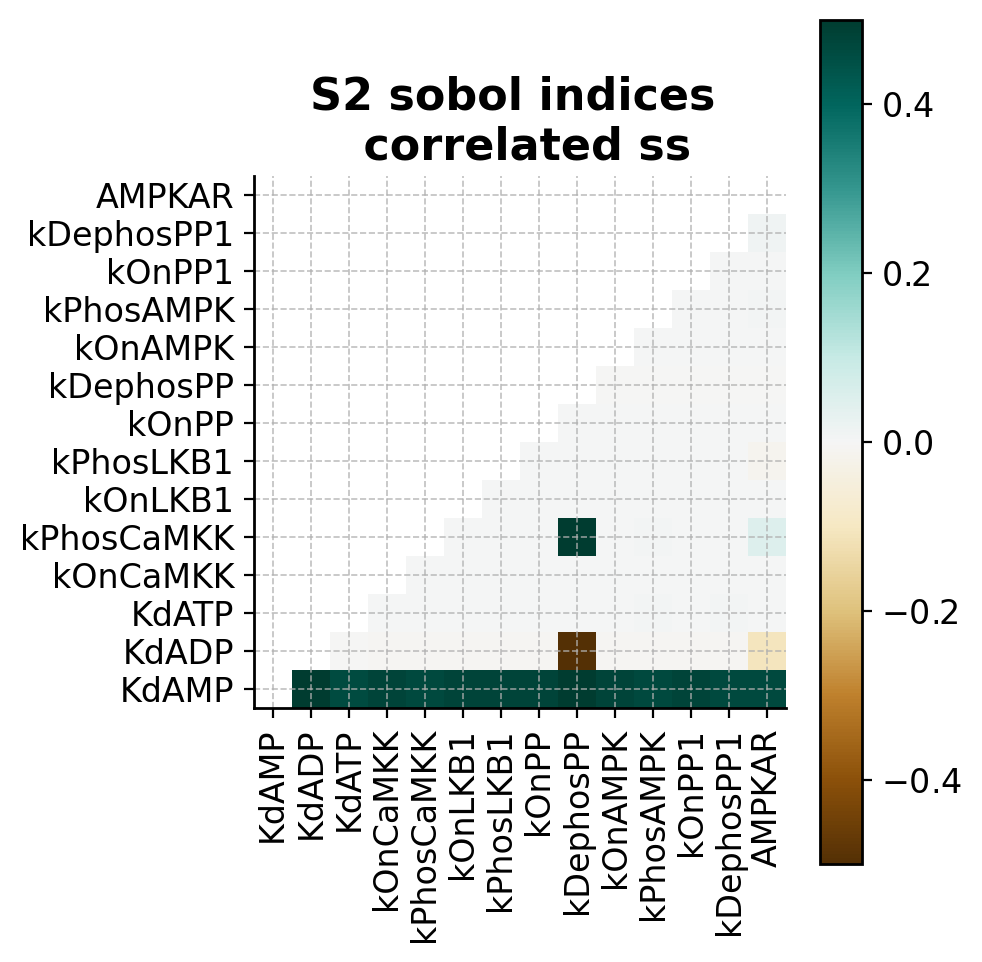

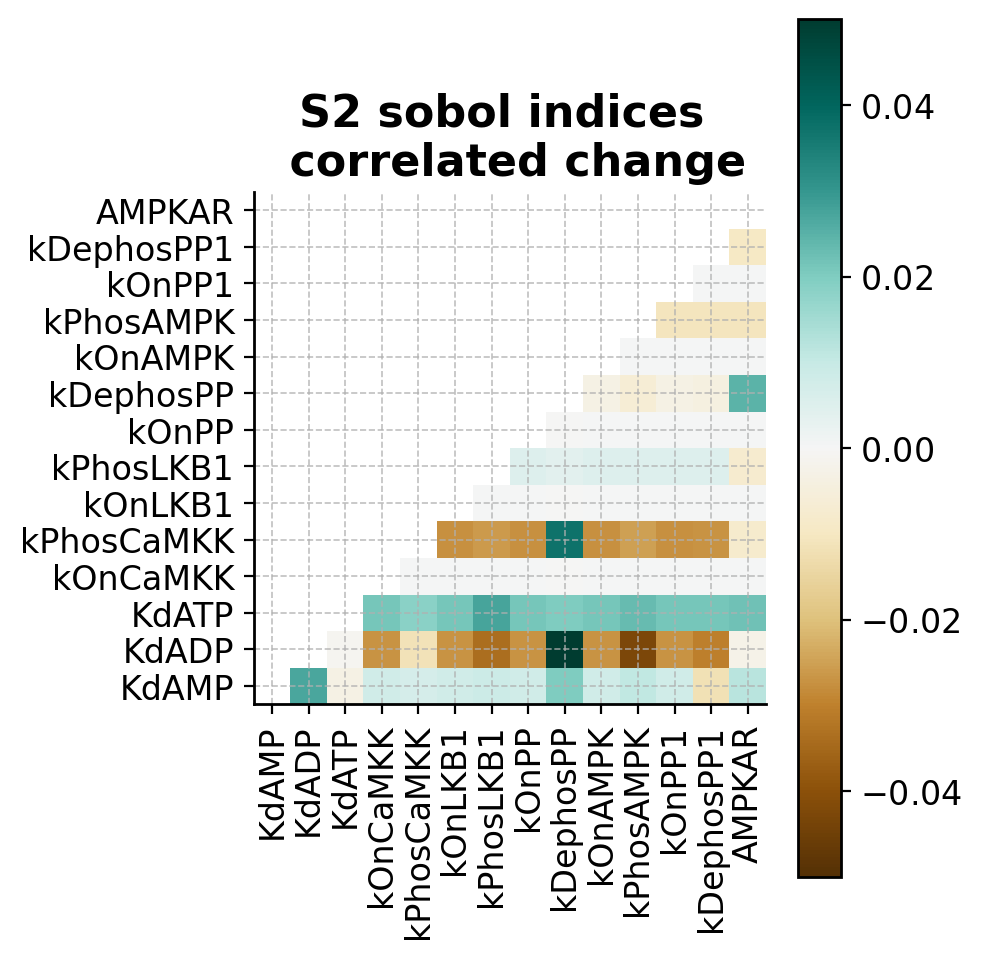

In [150]:
# plot second order
fig, ax = plt.subplots(figsize=(5,5))
cf = ax.pcolormesh(Si_sobol_ss['S2'], vmin=-0.011, vmax=0.011, cmap='BrBG')
fig.colorbar(cf, ax=ax)
ax.set_xticks(np.arange(0,len(param_names_MA))+0.5, labels=param_names_MA, rotation='vertical')
ax.set_yticks(np.arange(0,len(param_names_MA))+0.5, labels=param_names_MA)
ax.grid(True)
ax.set_aspect('equal')
ax.set_title('S2 sobol indices \n uncorrelated ss')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_S2_ss.pdf')

# plot second order
fig, ax = plt.subplots(figsize=(5,5))
cf = ax.pcolormesh(Si_sobol_delta['S2'], vmin=-0.05, vmax=0.05, cmap='BrBG')
fig.colorbar(cf, ax=ax)
ax.set_xticks(np.arange(0,len(param_names_MA))+0.5, labels=param_names_MA, rotation='vertical')
ax.set_yticks(np.arange(0,len(param_names_MA))+0.5, labels=param_names_MA)
ax.grid(True)
ax.set_aspect('equal')
ax.set_title('S2 sobol indices \n uncorrelated change')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_S2_delta.pdf')

# plot second order
fig, ax = plt.subplots(figsize=(5,5))
cf = ax.pcolormesh(Si_sobol_corr_ss['S2'], vmin=-0.5, vmax=0.5, cmap='BrBG')
fig.colorbar(cf, ax=ax)
ax.set_xticks(np.arange(0,len(param_names_MA))+0.5, labels=param_names_MA, rotation='vertical')
ax.set_yticks(np.arange(0,len(param_names_MA))+0.5, labels=param_names_MA)
ax.grid(True)
ax.set_aspect('equal')
ax.set_title('S2 sobol indices \n correlated ss')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_S2_corr_ss.pdf')

# plot second order
fig, ax = plt.subplots(figsize=(5,5))
cf = ax.pcolormesh(Si_sobol_corr_delta['S2'], vmin=-0.05, vmax=0.05, cmap='BrBG')
fig.colorbar(cf, ax=ax)
ax.set_xticks(np.arange(0,len(param_names_MA))+0.5, labels=param_names_MA, rotation='vertical')
ax.set_yticks(np.arange(0,len(param_names_MA))+0.5, labels=param_names_MA)
ax.grid(True)
ax.set_aspect('equal')
ax.set_title('S2 sobol indices \n correlated change')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_S2_corr_delta.pdf')

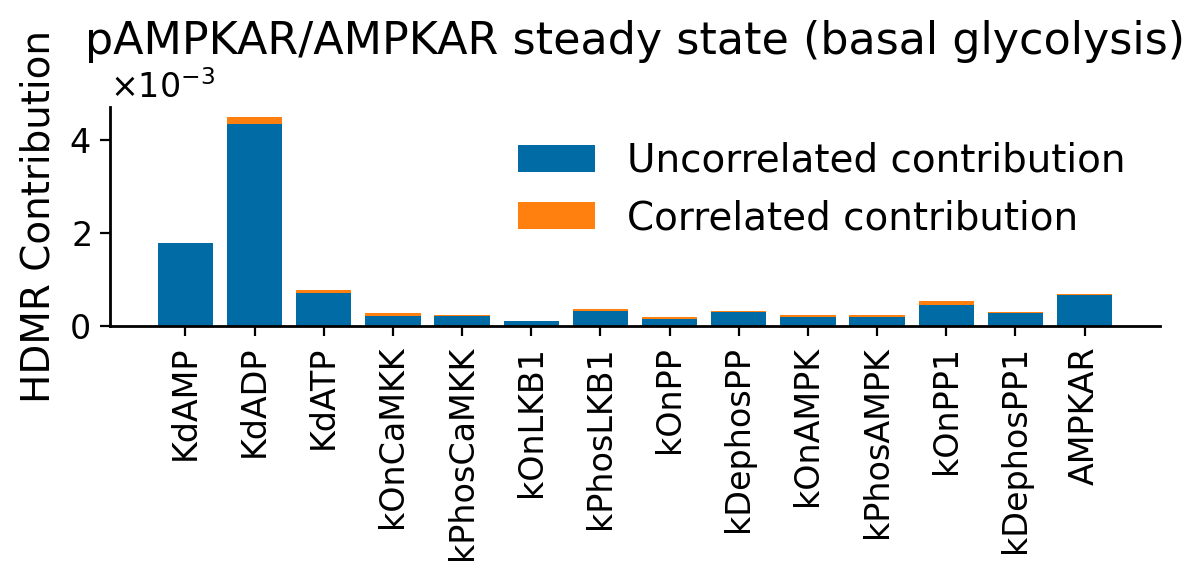

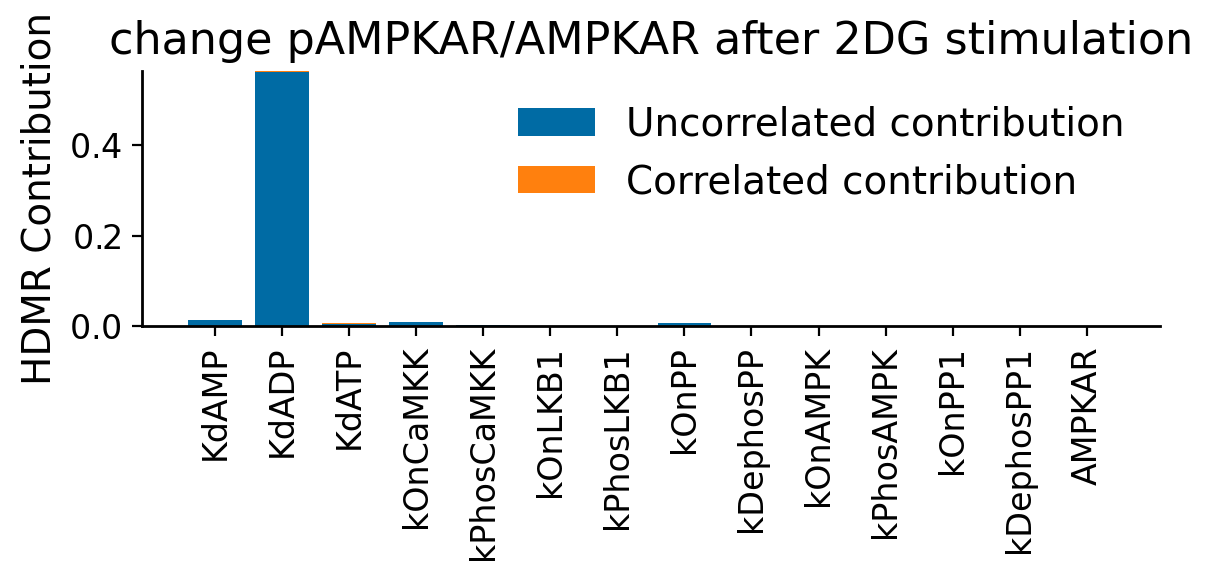

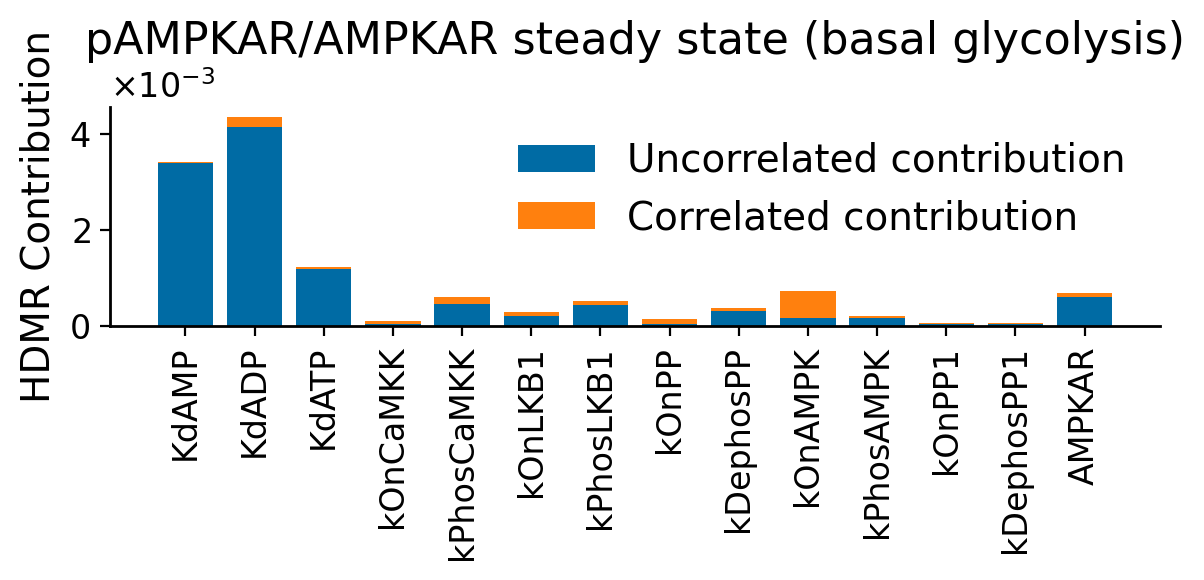

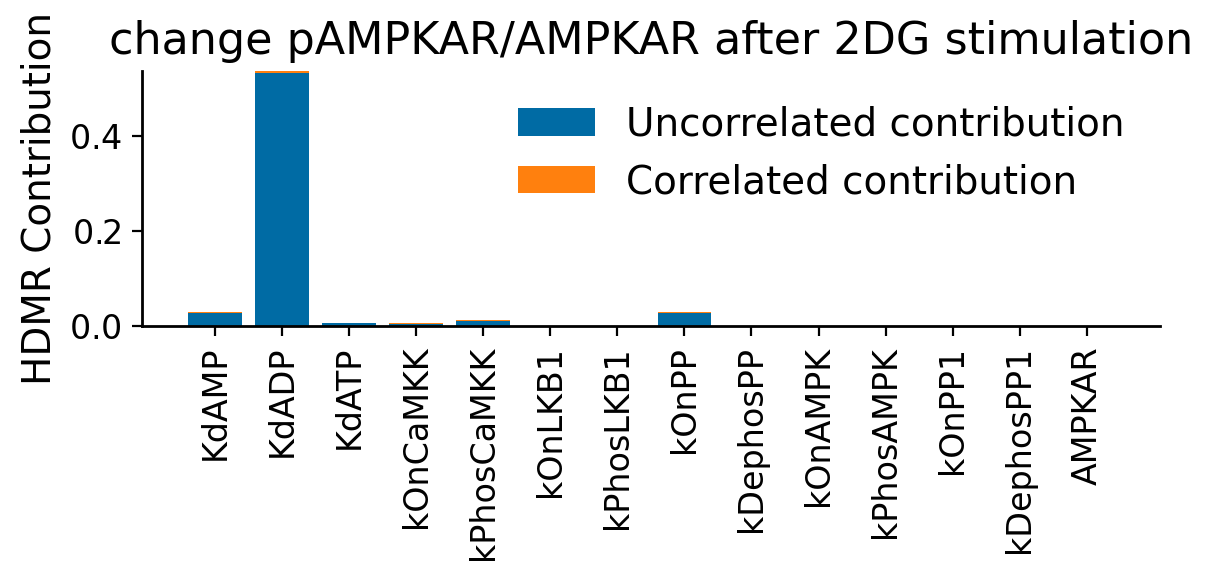

In [151]:
# now visualize the HDMR indices
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,len(Si_hdmr_ss['Sa'][0:14])), Si_hdmr_ss['Sa'][0:14],bottom=np.zeros(len(Si_hdmr_ss['Sa'][0:14])), label='Uncorrelated contribution')
ax.bar(np.arange(0,len(Si_hdmr_ss['Sb'][0:14])), Si_hdmr_ss['Sb'][0:14],bottom=Si_hdmr_ss['Sa'][0:14], label='Correlated contribution')
plt.xticks(np.arange(0, len(Si_hdmr_ss['names'][0:14])), Si_hdmr_ss['names'][0:14], rotation='vertical')
plt.ylabel('HDMR Contribution')
plt.legend()
plt.title('pAMPKAR/AMPKAR steady state (basal glycolysis)', weight='normal')
plt.show()
fig.savefig('./MA_double_mech/GSA_MA_double_mech_hdmr_ss.pdf')

# now visualize the HDMR indices
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,len(Si_hdmr_delta['Sa'][0:14])), Si_hdmr_delta['Sa'][0:14],bottom=np.zeros(len(Si_hdmr_delta['Sa'][0:14])), label='Uncorrelated contribution')
ax.bar(np.arange(0,len(Si_hdmr_delta['Sb'][0:14])), Si_hdmr_delta['Sb'][0:14],bottom=Si_hdmr_delta['Sa'][0:14], label='Correlated contribution')
plt.xticks(np.arange(0, len(Si_hdmr_delta['names'][0:14])), Si_hdmr_delta['names'][0:14], rotation='vertical')
plt.ylabel('HDMR Contribution')
plt.legend()
plt.title('change pAMPKAR/AMPKAR after 2DG stimulation', weight='normal')
plt.show()
fig.savefig('./MA_double_mech/GSA_MA_double_mech_hdmr_delta.pdf')

# now visualize the HDMR indices
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,len(Si_hdmr_corr_ss['Sa'][0:14])), Si_hdmr_corr_ss['Sa'][0:14],bottom=np.zeros(len(Si_hdmr_corr_ss['Sa'][0:14])), label='Uncorrelated contribution')
ax.bar(np.arange(0,len(Si_hdmr_corr_ss['Sb'][0:14])), Si_hdmr_corr_ss['Sb'][0:14],bottom=Si_hdmr_corr_ss['Sa'][0:14], label='Correlated contribution')
plt.xticks(np.arange(0, len(Si_hdmr_corr_ss['names'][0:14])), Si_hdmr_corr_ss['names'][0:14], rotation='vertical')
plt.ylabel('HDMR Contribution')
plt.legend()
plt.title('pAMPKAR/AMPKAR steady state (basal glycolysis)', weight='normal')
plt.show()
fig.savefig('./MA_double_mech/GSA_MA_double_mech_hdmr_corr_ss.pdf')

# now visualize the HDMR indices
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,len(Si_hdmr_corr_delta['Sa'][0:14])), Si_hdmr_corr_delta['Sa'][0:14],bottom=np.zeros(len(Si_hdmr_corr_delta['Sa'][0:14])), label='Uncorrelated contribution')
ax.bar(np.arange(0,len(Si_hdmr_corr_delta['Sb'][0:14])), Si_hdmr_corr_delta['Sb'][0:14],bottom=Si_hdmr_corr_delta['Sa'][0:14], label='Correlated contribution')
plt.xticks(np.arange(0, len(Si_hdmr_corr_delta['names'][0:14])), Si_hdmr_corr_delta['names'][0:14], rotation='vertical')
plt.ylabel('HDMR Contribution')
plt.legend()
plt.title('change pAMPKAR/AMPKAR after 2DG stimulation', weight='normal')
plt.show()
fig.savefig('./MA_double_mech/GSA_MA_double_mech_hdmr_corr_delta.pdf')
